# Parametric working memory

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from low_rank_rnn.analysis import (
    connectivity_covariance,
    connectivity_vectors,
    delay_diagnostics,
    delay_eigenvalues,
)
from low_rank_rnn.data import variable_delay as delay_task
from low_rank_rnn.model import LowRankRNN
from low_rank_rnn.plotting import (
    COLORS,
    plot_connectivity_covariance,
    plot_connectivity_pairs,
    set_plot_style,
)
from low_rank_rnn.training import decision_loss, train_model, train_variable_delay

set_plot_style()

### Task configuration

The values below come directly from the project brief. Keeping them together makes the future experiment easy to review and modify.

In [2]:
BASE_SEED = 2026
TRIAL_LENGTH = 80
FIRST_STIMULUS_WINDOW = (5, 10)
SECOND_STIMULUS_WINDOW = (60, 70)
DECISION_STEPS = 5

FREQUENCIES = np.array([10, 14, 18, 22, 26, 30, 34], dtype=float)
MIN_FREQUENCY = float(FREQUENCIES.min())
MAX_FREQUENCY = float(FREQUENCIES.max())

NUM_TRAIN_TRIALS = 200
NUM_TEST_TRIALS = 160
NUM_UNITS = 128
RANK = 2
TARGET_LOSS = 5e-3

rng = np.random.default_rng(BASE_SEED)
_ = torch.manual_seed(BASE_SEED)

## 2. Generate task trials

Each trial has a first stimulus during $5 \leq t \leq 10$, a delay, and a second stimulus during $60 \leq t \leq 70$; the input is zero at all other time steps. Frequencies $f_1$ and $f_2$ are sampled independently and uniformly from `FREQUENCIES`.

The scalar stimulus values are

$$
u_i = \frac{1}{f_{\max} - f_{\min}}
\left(f_i - \frac{f_{\max} + f_{\min}}{2}\right),
\qquad i \in \{1, 2\},
$$

and the target is the normalized difference

$$
y = \frac{f_1 - f_2}{f_{\max} - f_{\min}}.
$$

Future data-generation code should return batched inputs, targets, and enough trial metadata to inspect the sampled frequency pairs.

In [3]:
def generate_parametric_working_memory_trials(num_trials, trial_length, rng):
    f_i = rng.choice(FREQUENCIES, size=(num_trials, 2))
    u_i = (f_i - (MAX_FREQUENCY + MIN_FREQUENCY) / 2) / (MAX_FREQUENCY - MIN_FREQUENCY)
    y = (f_i[:, 0] - f_i[:, 1]) / (MAX_FREQUENCY - MIN_FREQUENCY)
    first_start, first_end = FIRST_STIMULUS_WINDOW
    second_start, second_end = SECOND_STIMULUS_WINDOW
    u = np.zeros((num_trials, trial_length))
    u[:, first_start : first_end + 1] = u_i[:, 0, None]
    u[:, second_start : second_end + 1] = u_i[:, 1, None]
    return u, y, f_i


### Check representative trials

Plot several inputs and verify both stimulus windows, sampled frequency pairs, normalized stimulus values, and targets before training.

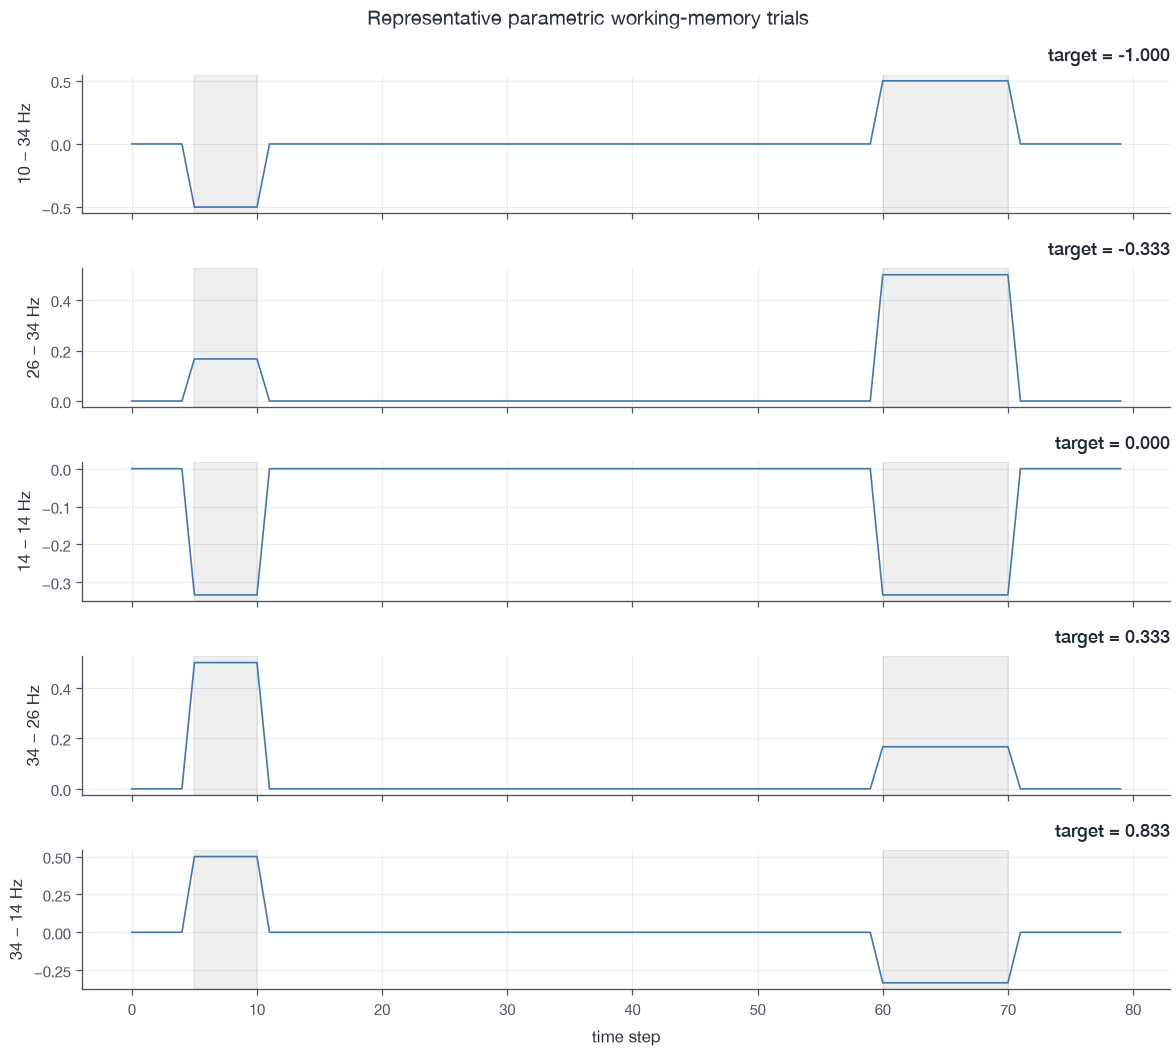

In [4]:
def plot_parametric_working_memory_trials(
    inputs,
    targets,
    frequencies,
    *,
    num_trials=5,
):
    num_plotted = min(num_trials, len(inputs))
    sorted_trials = np.argsort(targets)
    positions = np.linspace(0, len(sorted_trials) - 1, num_plotted, dtype=int)
    selected_trials = sorted_trials[positions]

    time_steps = np.arange(inputs.shape[1])
    fig, axes = plt.subplots(
        num_plotted,
        1,
        figsize=(10, 1.8 * num_plotted),
        sharex=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for trial, ax in zip(selected_trials, axes):
        ax.plot(time_steps, inputs[trial], lw=1)
        ax.axvspan(*FIRST_STIMULUS_WINDOW, color="gray", alpha=0.12)
        ax.axvspan(*SECOND_STIMULUS_WINDOW, color="gray", alpha=0.12)
        f_1, f_2 = frequencies[trial]
        ax.set_ylabel(f"{f_1:g} − {f_2:g} Hz")
        ax.set_title(f"target = {targets[trial]:.3f}", loc="right")

    axes[-1].set_xlabel("time step")
    fig.suptitle("Representative parametric working-memory trials")
    fig.tight_layout()
    return fig, axes


train_inputs, train_targets, train_frequencies = generate_parametric_working_memory_trials(
    NUM_TRAIN_TRIALS,
    TRIAL_LENGTH,
    rng,
)
test_inputs, test_targets, test_frequencies = generate_parametric_working_memory_trials(
    NUM_TEST_TRIALS,
    TRIAL_LENGTH,
    rng,
)

plot_parametric_working_memory_trials(
    train_inputs,
    train_targets,
    train_frequencies,
)
plt.show()

## 3. Initialize a rank-two RNN

Extend the current low-rank model from rank one to arbitrary rank, then initialize this experiment with `NUM_UNITS = 128` and `RANK = 2`. Keep the notebook focused on experiment orchestration; reusable model code should live in the package.

In [5]:
model = LowRankRNN(NUM_UNITS, rank=2)
model

LowRankRNN()

## 4. Train

Minimize mean squared error between the target and the network output over the final `DECISION_STEPS = 5` time steps. The project brief gives a target loss below `5e-3`.

Epoch 100: loss=0.115290
Epoch 200: loss=0.115002
Epoch 300: loss=0.114905
Epoch 400: loss=0.004609
Epoch 500: loss=0.000831
Epoch 600: loss=0.000548
Epoch 700: loss=0.000365
Epoch 800: loss=0.000247
Epoch 900: loss=0.000197
Epoch 1000: loss=0.000172
Final training loss: 0.000172


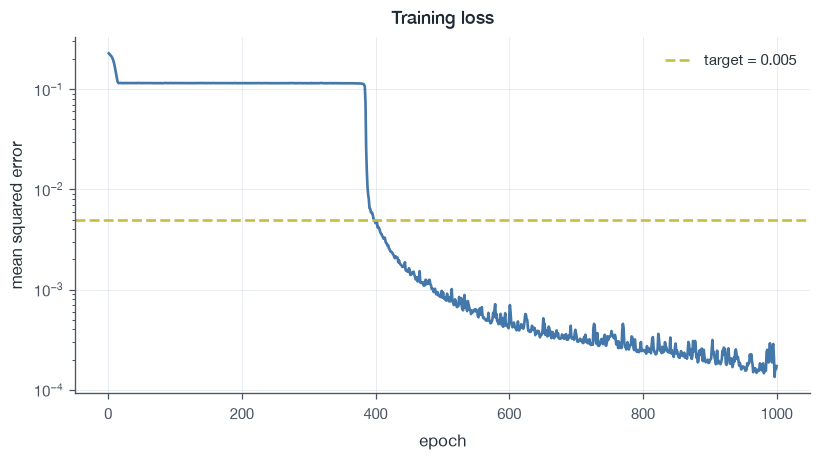

In [6]:
train_input_tensor = torch.as_tensor(train_inputs, dtype=torch.float32)
train_target_tensor = torch.as_tensor(train_targets, dtype=torch.float32)

losses = train_model(
    model,
    train_input_tensor,
    train_target_tensor,
    decision_steps=DECISION_STEPS,
    log_every=100,
)
print(f"Final training loss: {losses[-1]:.6f}")

epochs = np.arange(1, len(losses) + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, losses)
ax.axhline(TARGET_LOSS, color="C3", ls="--", label=f"target = {TARGET_LOSS:g}")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("mean squared error")
ax.set_title("Training loss")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Evaluate

Evaluate the trained network on fresh trials. Inspect held-out decision-window error and plot representative outputs alongside their continuous targets.

Test MSE over the final 5 time steps: 0.000250


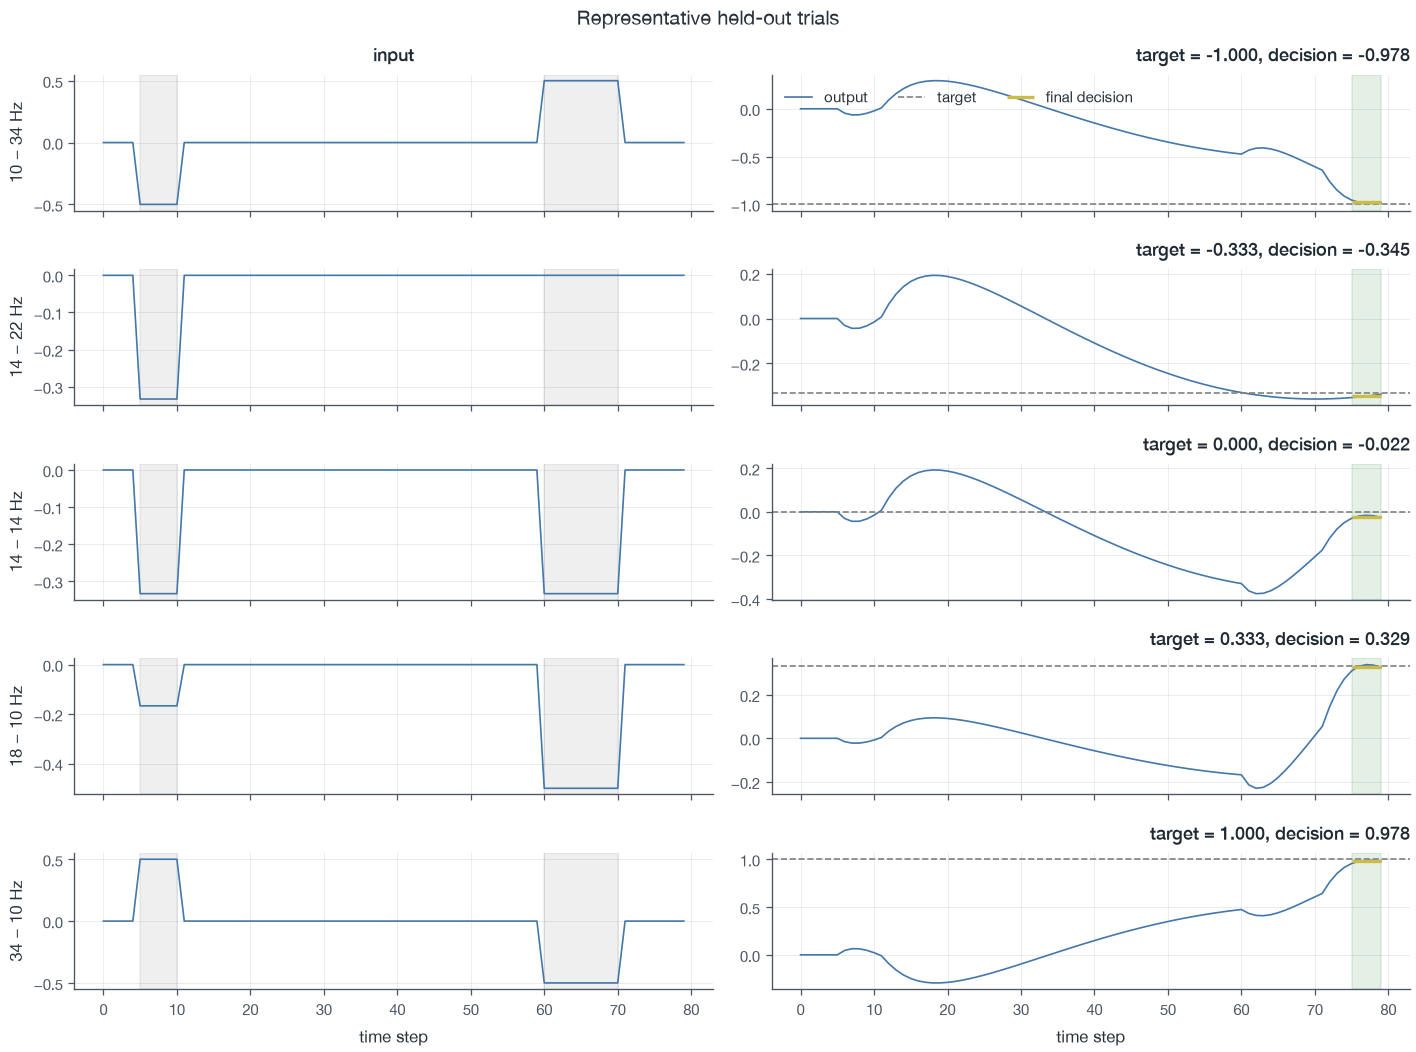

In [7]:
test_input_tensor = torch.as_tensor(test_inputs, dtype=torch.float32)
test_target_tensor = torch.as_tensor(test_targets, dtype=torch.float32)

model.eval()
with torch.no_grad():
    test_outputs, test_states = model(test_input_tensor)
    test_loss = decision_loss(
        test_outputs,
        test_target_tensor,
        decision_steps=DECISION_STEPS,
    )

print(f"Test MSE over the final {DECISION_STEPS} time steps: {test_loss.item():.6f}")

num_examples = 5
sorted_trials = np.argsort(test_targets)
positions = np.linspace(0, len(sorted_trials) - 1, num_examples, dtype=int)
example_trials = sorted_trials[positions]
decision_start = TRIAL_LENGTH - DECISION_STEPS

fig, axes = plt.subplots(
    num_examples,
    2,
    figsize=(12, 1.8 * num_examples),
    sharex=True,
    squeeze=False,
)
for trial, (input_axis, output_axis) in zip(example_trials, axes):
    output = test_outputs[trial].cpu().numpy()
    target = test_targets[trial]
    decision = output[-DECISION_STEPS:].mean()
    f_1, f_2 = test_frequencies[trial]

    input_axis.plot(test_inputs[trial], lw=1)
    input_axis.axvspan(*FIRST_STIMULUS_WINDOW, color="gray", alpha=0.12)
    input_axis.axvspan(*SECOND_STIMULUS_WINDOW, color="gray", alpha=0.12)
    input_axis.set_ylabel(f"{f_1:g} − {f_2:g} Hz")

    output_axis.plot(output, lw=1, label="output")
    output_axis.axhline(target, color="gray", ls="--", lw=1, label="target")
    output_axis.hlines(
        decision,
        decision_start,
        TRIAL_LENGTH - 1,
        color="C3",
        lw=2,
        label="final decision",
    )
    output_axis.axvspan(decision_start, TRIAL_LENGTH - 1, color="C2", alpha=0.12)
    output_axis.set_title(f"target = {target:.3f}, decision = {decision:.3f}", loc="right")

axes[0, 0].set_title("input")
axes[0, 1].legend(loc="upper left", ncols=3)
axes[-1, 0].set_xlabel("time step")
axes[-1, 1].set_xlabel("time step")
fig.suptitle("Representative held-out trials")
fig.tight_layout()
plt.show()

## 6. Analyze connectivity

Visualize the trained loading vectors and their covariance structure. Compare the learned patterns with Figure 3b of Dubreuil et al. and use them to reason about why the task requires rank two.

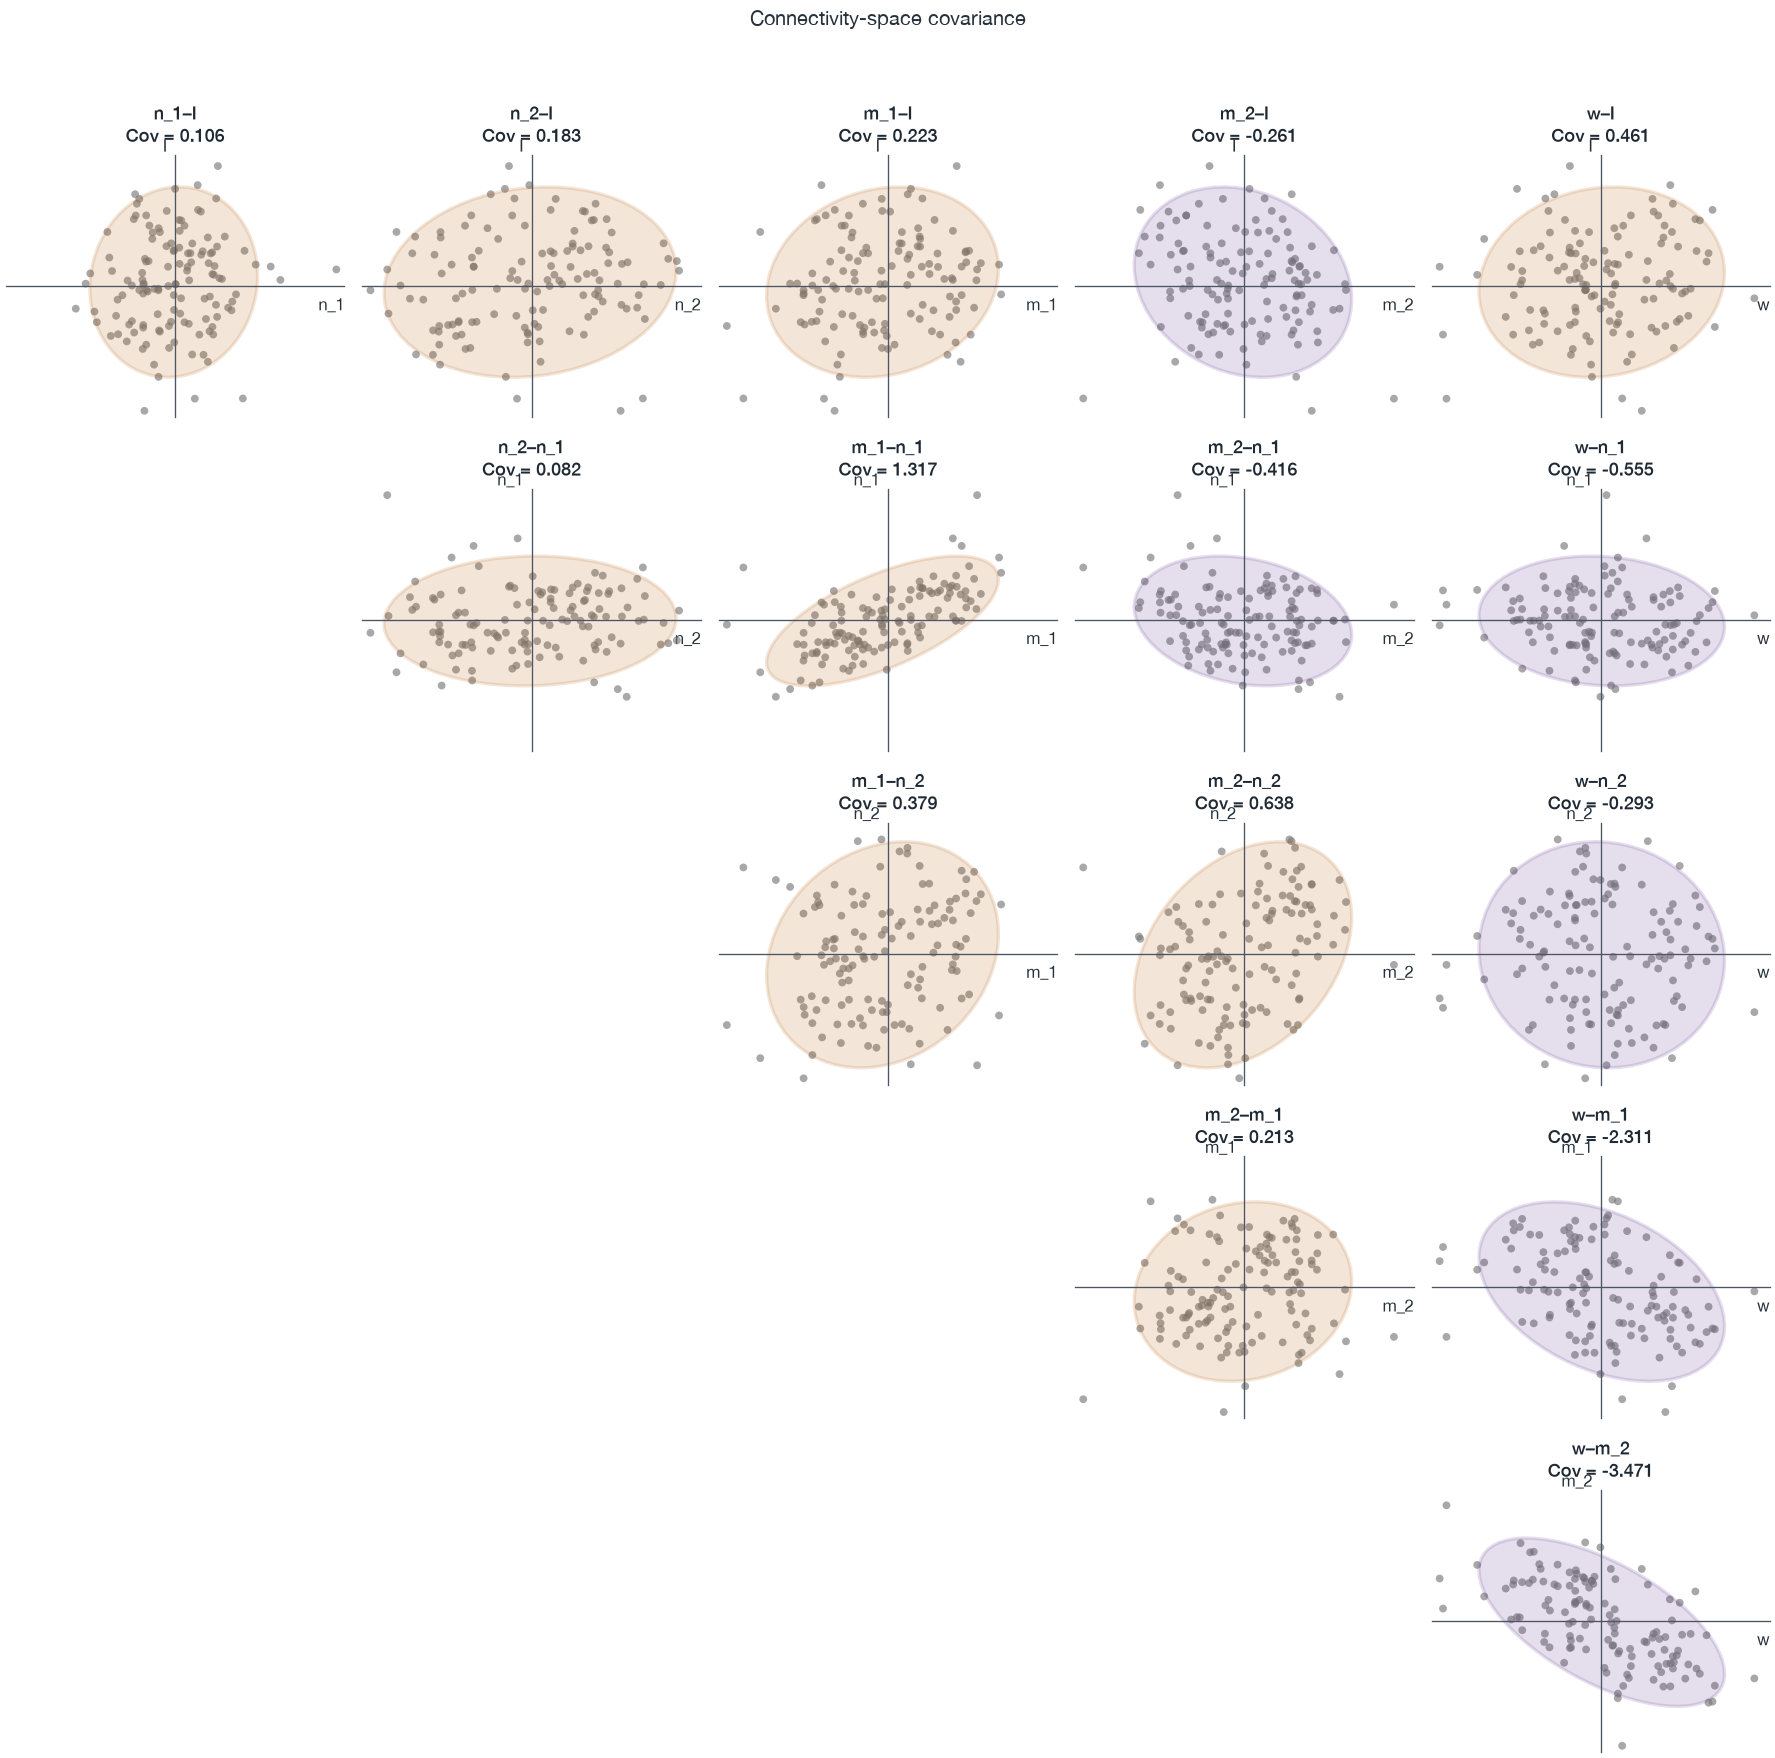

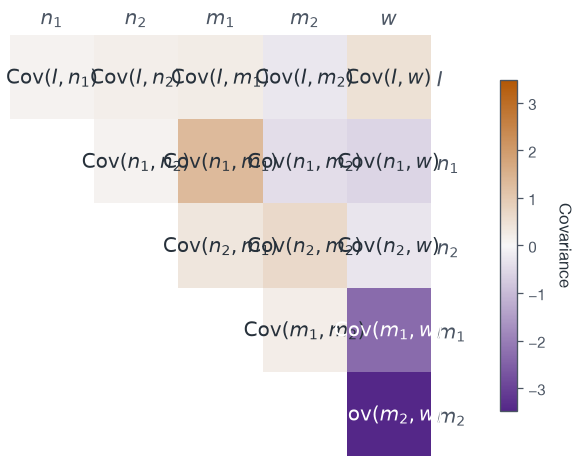

In [8]:
vectors = connectivity_vectors(model)
fig, axes = plot_connectivity_pairs(
    vectors,
    row_names=("I", "n_1", "n_2", "m_1", "m_2"),
    column_names=("n_1", "n_2", "m_1", "m_2", "w"),
)
plt.show()

names, covariance = connectivity_covariance(vectors)
fig, ax = plot_connectivity_covariance(names, covariance)
plt.show()

## 7. Project latent dynamics

Plot each input next to the corresponding hidden-state trajectory projected onto an orthonormal basis for $\operatorname{span}(m_1, m_2, I)$. Matching colors connect each stimulus pair across the two views.

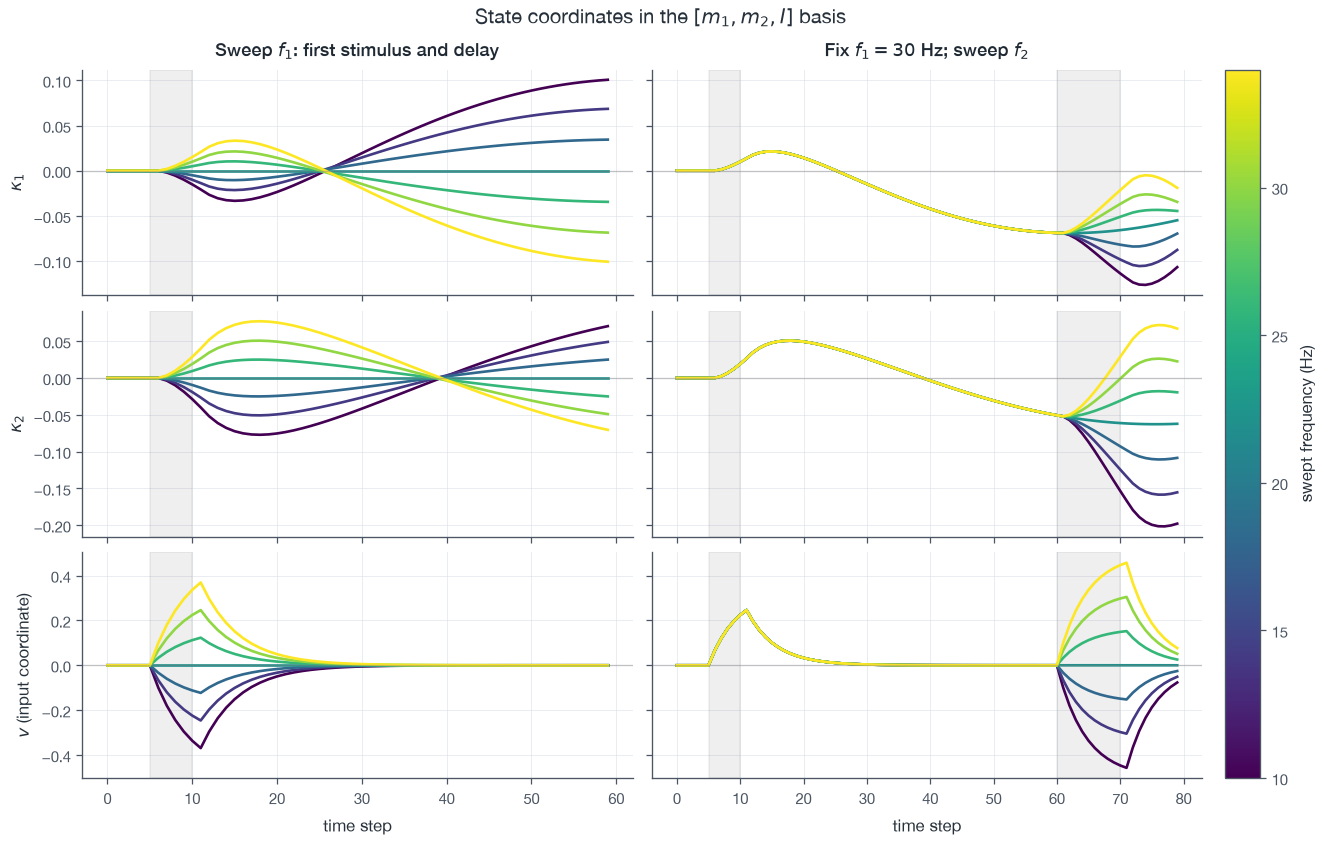

In [9]:
# x(t) = m_1 kappa_1(t) + m_2 kappa_2(t) + I v(t)
basis = torch.column_stack((model.m.detach(), model.I.detach()))
basis_inverse = torch.linalg.pinv(basis)


def state_coordinates_for_sweep(f_1_values, f_2_values):
    frequencies = np.column_stack((f_1_values, f_2_values))
    amplitudes = (
        frequencies - (MAX_FREQUENCY + MIN_FREQUENCY) / 2
    ) / (MAX_FREQUENCY - MIN_FREQUENCY)

    inputs = np.zeros((len(frequencies), TRIAL_LENGTH), dtype=np.float32)
    for values, (start, end) in zip(
        amplitudes.T, (FIRST_STIMULUS_WINDOW, SECOND_STIMULUS_WINDOW)
    ):
        inputs[:, start : end + 1] = values[:, None]

    with torch.no_grad():
        _, states = model(torch.as_tensor(inputs))

    return (states @ basis_inverse.T).cpu().numpy()


neutral_frequency = (MIN_FREQUENCY + MAX_FREQUENCY) / 2
f_1_coordinates = state_coordinates_for_sweep(
    FREQUENCIES, np.full_like(FREQUENCIES, neutral_frequency)
)
f_2_coordinates = state_coordinates_for_sweep(
    np.full_like(FREQUENCIES, 30.0), FREQUENCIES
)

time_steps = np.arange(TRIAL_LENGTH)
color_norm = plt.Normalize(MIN_FREQUENCY, MAX_FREQUENCY)
color_map = plt.get_cmap("viridis")
fig, axes = plt.subplots(
    3, 2, figsize=(11, 7), sharex="col", sharey="row", constrained_layout=True
)

panels = (
    (f_1_coordinates, SECOND_STIMULUS_WINDOW[0], (FIRST_STIMULUS_WINDOW,)),
    (
        f_2_coordinates,
        TRIAL_LENGTH,
        (FIRST_STIMULUS_WINDOW, SECOND_STIMULUS_WINDOW),
    ),
)
for column, (coordinates, stop, windows) in enumerate(panels):
    for trial, frequency in enumerate(FREQUENCIES):
        color = color_map(color_norm(frequency))
        for row in range(3):
            axes[row, column].plot(
                time_steps[:stop], coordinates[trial, :stop, row], color=color
            )
    for axis in axes[:, column]:
        axis.axhline(0, color="gray", lw=0.8, alpha=0.4)
        for start, end in windows:
            axis.axvspan(start, end, color="gray", alpha=0.12)

axes[0, 0].set_title(r"Sweep $f_1$: first stimulus and delay")
axes[0, 1].set_title(r"Fix $f_1=30$ Hz; sweep $f_2$")
for axis, label in zip(
    axes[:, 0], (r"$\kappa_1$", r"$\kappa_2$", r"$v$ (input coordinate)")
):
    axis.set_ylabel(label)
for axis in axes[-1]:
    axis.set_xlabel("time step")

fig.colorbar(
    plt.cm.ScalarMappable(norm=color_norm, cmap=color_map),
    ax=axes,
    label="swept frequency (Hz)",
    pad=0.02,
)
fig.suptitle(r"State coordinates in the $[m_1, m_2, I]$ basis")
plt.show()

## 8. Test the loading-space Gaussian approximation

Fit a six-dimensional Gaussian to the connectivity loadings, resample networks from it, and compare their connectivity statistics and task performance with the trained network.

In [10]:
# TODO: Fit, sample, and evaluate the six-dimensional loading Gaussian.

## 9. Build the two-dimensional equivalent circuit

Use the learned covariance parameters to simulate the effective dynamics for $\kappa_1$ and $\kappa_2$, then compare the reduced circuit with the full network on matched inputs.

In [11]:
# TODO: Simulate and evaluate the two-dimensional equivalent circuit.

## 10. Randomized delays, and what a delay curriculum buys

The paper samples the blank delay uniformly from 500–2000 ms, which is 25 to 100
steps at the model's 20 ms time step. Stimulus 1 stays fixed in time while
stimulus 2 and the five-step decision window move together, so trials are padded
to a common length and carry a per-trial decision mask.
`low_rank_rnn.data.variable_delay` builds them, and `train_variable_delay` walks
a network through a sequence of delay ranges, keeping one optimizer throughout.

Two cohorts of four seeds each differ *only* in the order the delays arrive:

- **curriculum** — 300 epochs on each of 100–500, 500–1000, 500–1500, 500–2000 ms
- **no curriculum** — all 1200 epochs on the full 500–2000 ms range

Same seeds, same random initialization, same number of gradient steps, so any
difference between the cohorts is down to the schedule alone.

Latent coordinates have no absolute scale — $m$ can shrink while the fixed
readout compensates — so the trajectory panels below plot each network against
its own $f_1$ separation at delay onset, and `retained_span` measures what
fraction of that separation survives to each delay.

### What the run shows

The curriculum reaches the line attractor in **4 of 4** seeds: held-out error
0.002–0.004 across every delay, memory states drifting 1.3–2.7% of the manifold
span, and a leading eigenvalue within 0.013 of zero. Training on the full range
from the start reaches it in **1 of 4**.

The other three stall at MSE $\approx 0.113$, and that number is diagnostic. The
best constant output would score 0.222; reporting $-f_2$ alone and forgetting
$f_1$ leaves exactly $0.111$. Those three networks are answering with the
stimulus still in front of them and retaining nothing about the first one.

The failure is a *collapsed* memory rather than an unstable one. They enter the
delay with a normal stimulus-driven separation, lose it within about 400 ms, and
sit at exactly zero well before even the shortest delay ends. Their leading
eigenvalue is $\approx -1$: the latent state decays at the intrinsic leak rate
with no recurrent support holding it up.

Neither cohort settles into rotational dynamics, unlike the fixed-delay networks
of section 11. Every eigenvalue in all eight is real to within numerical
precision. The latent state does swing once early on as the non-memory mode
collapses — each curve crosses zero at most once, always inside the first 120 ms
— but it is stationary after that, moving only 1.3–2.7% of the manifold span
between 500 and 2000 ms.

What separates success from failure is a single number: successful networks tune
one eigenvalue of the recurrent overlap $C = n^\top m / N$ to within 2% of 1,
which places the corresponding mode of $C - I$ at zero, while the collapsed
networks leave both eigenvalues of $C$ negative.

Since one of four control networks does find the line attractor, the curriculum
is not enabling a solution that was otherwise unreachable. It makes an unreliable
outcome reliable, which is a claim about optimization rather than expressivity.
Four seeds per arm is enough to see a 4/4 versus 1/4 split, not enough to pin
down the underlying success rate. Repeating both arms with minibatch training
instead of full batch reproduces the same split.

In [12]:
# Two matched cohorts: same seeds, same 1200 epochs, different delay schedules.
COHORT_SEEDS = (2026, 2027, 2028, 2029)
CURRICULUM_STAGES = (
    np.arange(5, 26),
    np.arange(25, 51),
    np.arange(25, 76),
    delay_task.DELAYS,
)
STAGE_EPOCHS = 300
PROBE_DELAYS = delay_task.DELAYS[::5]


def train_cohort(stages, epochs_per_stage):
    """Train one network per seed and pair each with its delay diagnostics."""
    cohort = []
    for seed in COHORT_SEEDS:
        torch.manual_seed(seed)
        model = LowRankRNN(NUM_UNITS, rank=RANK)
        losses = train_variable_delay(
            model,
            stages,
            rng=np.random.default_rng(seed),
            epochs_per_stage=epochs_per_stage,
        )
        cohort.append(
            {
                "seed": seed,
                "model": model,
                "losses": np.asarray(losses),
                **delay_diagnostics(model, probe_delays=PROBE_DELAYS),
            }
        )
    return cohort


def describe_cohort(cohort, label):
    for result in cohort:
        print(
            f"{label} seed {result['seed']}: "
            f"train MSE={result['losses'][-1]:.4f}, "
            f"max probe MSE={result['probe_mse'].max():.4f}, "
            f"drift={result['fractional_drift'][-1]:.1%}, "
            f"max |Im λ|={np.abs(result['eigenvalues'].imag).max():.4f}"
        )


# The control gets the whole delay range for all 1200 epochs, so the two
# cohorts differ only in the order the delays are presented.
curriculum_cohort = train_cohort(CURRICULUM_STAGES, STAGE_EPOCHS)
baseline_cohort = train_cohort(
    (delay_task.DELAYS,),
    len(CURRICULUM_STAGES) * STAGE_EPOCHS,
)

describe_cohort(curriculum_cohort, "curriculum,   ")
describe_cohort(baseline_cohort, "no curriculum,")

curriculum,    seed 2026: train MSE=0.0028, max probe MSE=0.0029, drift=1.3%, max |Im λ|=0.0000
curriculum,    seed 2027: train MSE=0.0016, max probe MSE=0.0022, drift=1.8%, max |Im λ|=0.0000
curriculum,    seed 2028: train MSE=0.0020, max probe MSE=0.0023, drift=1.5%, max |Im λ|=0.0000
curriculum,    seed 2029: train MSE=0.0037, max probe MSE=0.0041, drift=2.7%, max |Im λ|=0.0000
no curriculum, seed 2026: train MSE=0.1139, max probe MSE=0.1137, drift=28.7%, max |Im λ|=0.0000
no curriculum, seed 2027: train MSE=0.0020, max probe MSE=0.0022, drift=2.3%, max |Im λ|=0.0000
no curriculum, seed 2028: train MSE=0.1143, max probe MSE=0.1130, drift=28.6%, max |Im λ|=0.0000
no curriculum, seed 2029: train MSE=0.1127, max probe MSE=0.1130, drift=28.6%, max |Im λ|=0.0000


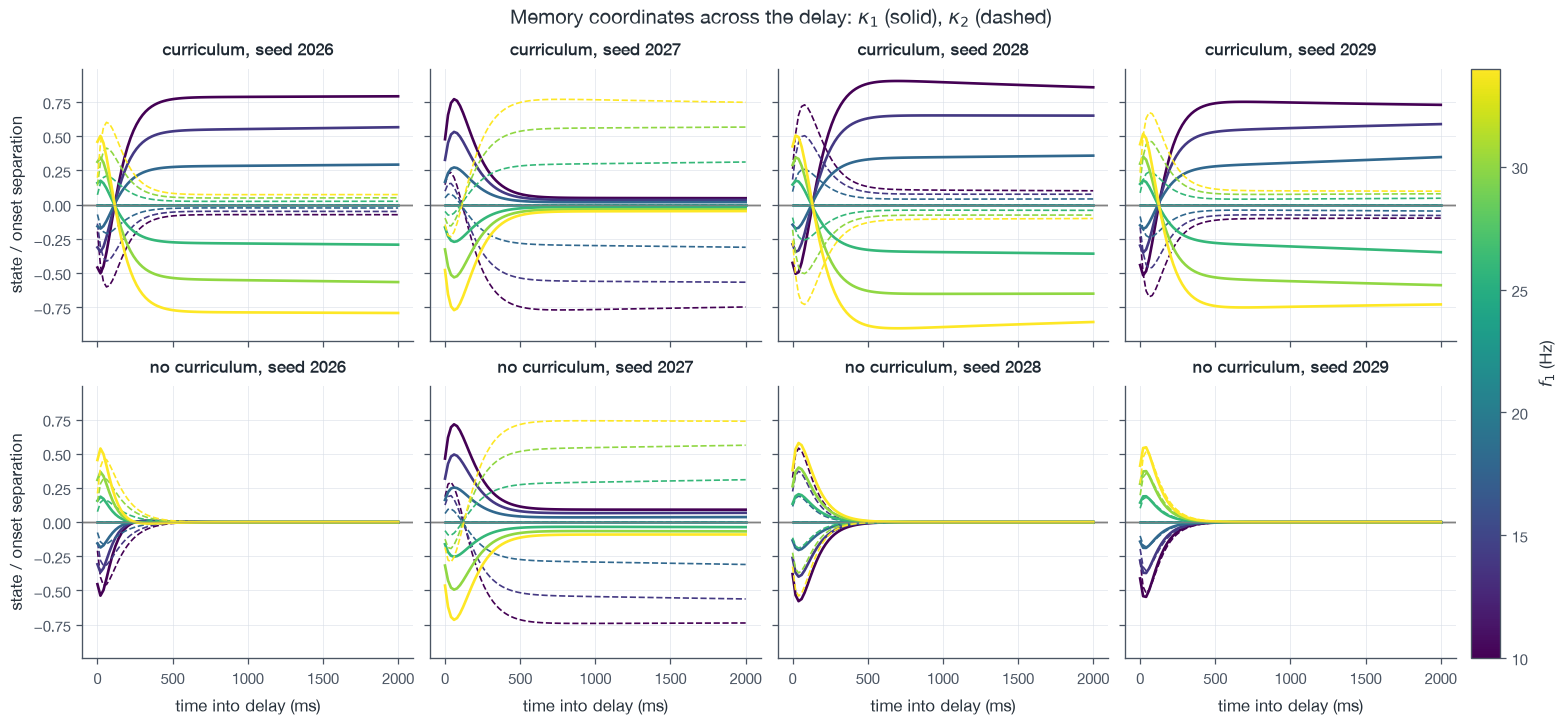

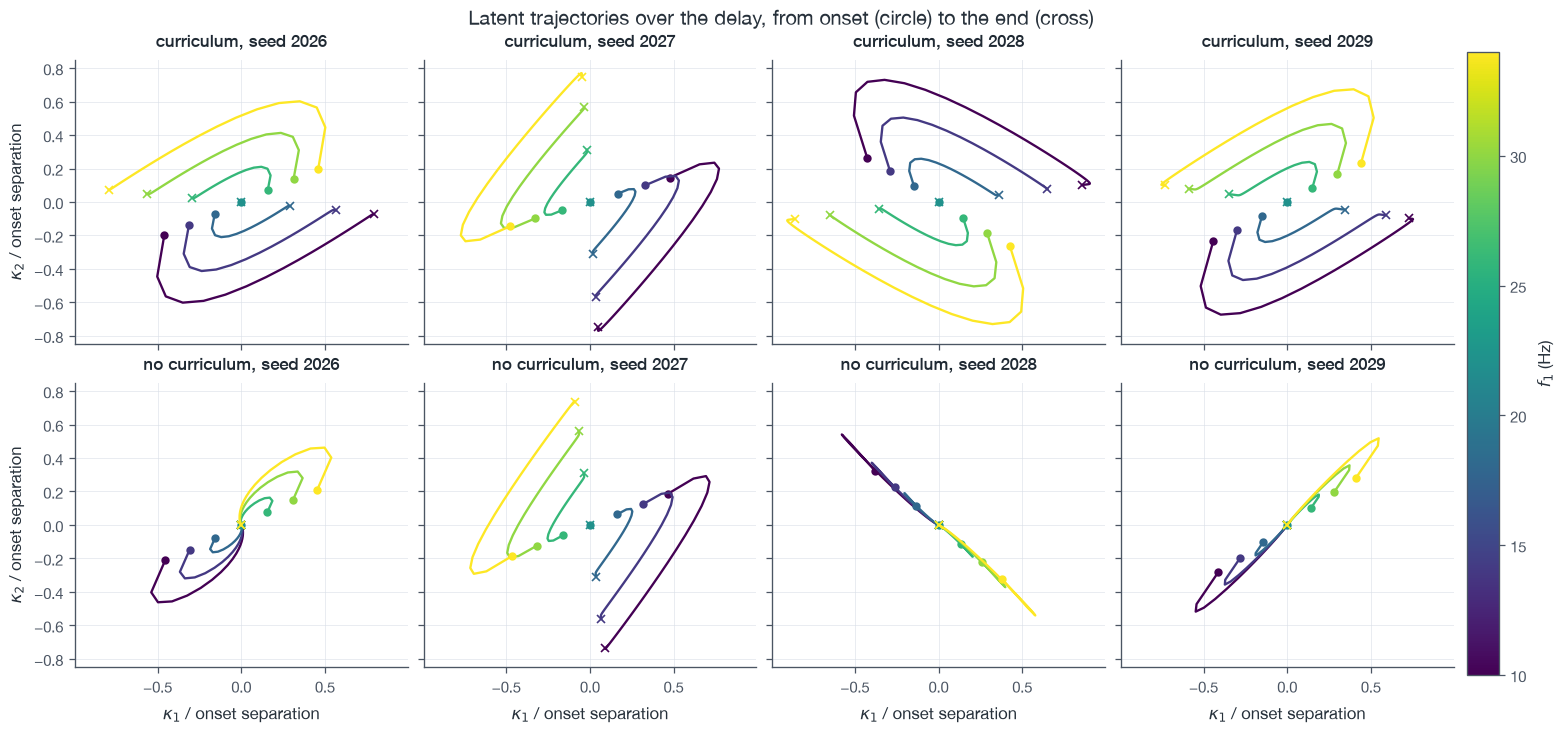

In [13]:
# Identical panels for every cohort: rows are the training schedule, columns the seed.
COHORTS = ((curriculum_cohort, "curriculum"), (baseline_cohort, "no curriculum"))


def onset_normalized(result):
    """Memory states in units of their own f_1 separation at delay onset.

    Latent coordinates carry no absolute scale, since ``m`` can shrink while the
    readout compensates. Measuring each network against its own starting
    separation puts every panel on a comparable axis.
    """
    coordinates = result["memory_coordinates"]
    return coordinates / np.linalg.norm(coordinates[-1, 0] - coordinates[0, 0])


def plot_cohort_grid(draw, title, cohorts=None):
    """Draw one panel per network, on axes shared across every cohort."""
    cohorts = COHORTS if cohorts is None else cohorts
    fig, axes = plt.subplots(
        len(cohorts),
        len(COHORT_SEEDS),
        figsize=(13, 3 * len(cohorts)),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    for row, (cohort, label) in zip(axes, cohorts):
        for axis, result in zip(row, cohort):
            trajectories = onset_normalized(result)
            for trial, frequency in enumerate(delay_task.FREQUENCIES):
                draw(axis, trajectories[trial], color_map(color_norm(frequency)))
            axis.set_title(f"{label}, seed {result['seed']}", fontsize=10)

    fig.colorbar(
        plt.cm.ScalarMappable(norm=color_norm, cmap=color_map),
        ax=axes,
        label=r"$f_1$ (Hz)",
        pad=0.01,
    )
    fig.suptitle(title)
    return fig, axes


def draw_time_course(axis, trajectory, color):
    time_ms = 20 * np.arange(len(trajectory))
    axis.plot(time_ms, trajectory[:, 0], color=color)
    axis.plot(time_ms, trajectory[:, 1], color=color, ls="--", lw=1)
    axis.axhline(0, color="gray", lw=0.8, alpha=0.4)


def draw_plane(axis, trajectory, color):
    axis.plot(trajectory[:, 0], trajectory[:, 1], color=color, lw=1.4)
    axis.plot(*trajectory[0], marker="o", ms=4, color=color)
    axis.plot(*trajectory[-1], marker="x", ms=5, color=color)
    axis.set_aspect("equal", adjustable="box")


fig, axes = plot_cohort_grid(
    draw_time_course,
    r"Memory coordinates across the delay: $\kappa_1$ (solid), $\kappa_2$ (dashed)",
)
for axis in axes[-1]:
    axis.set_xlabel("time into delay (ms)")
for row in axes:
    row[0].set_ylabel("state / onset separation")
plt.show()

fig, axes = plot_cohort_grid(
    draw_plane,
    "Latent trajectories over the delay, from onset (circle) to the end (cross)",
)
for axis in axes[-1]:
    axis.set_xlabel(r"$\kappa_1$ / onset separation")
for row in axes:
    row[0].set_ylabel(r"$\kappa_2$ / onset separation")
plt.show()

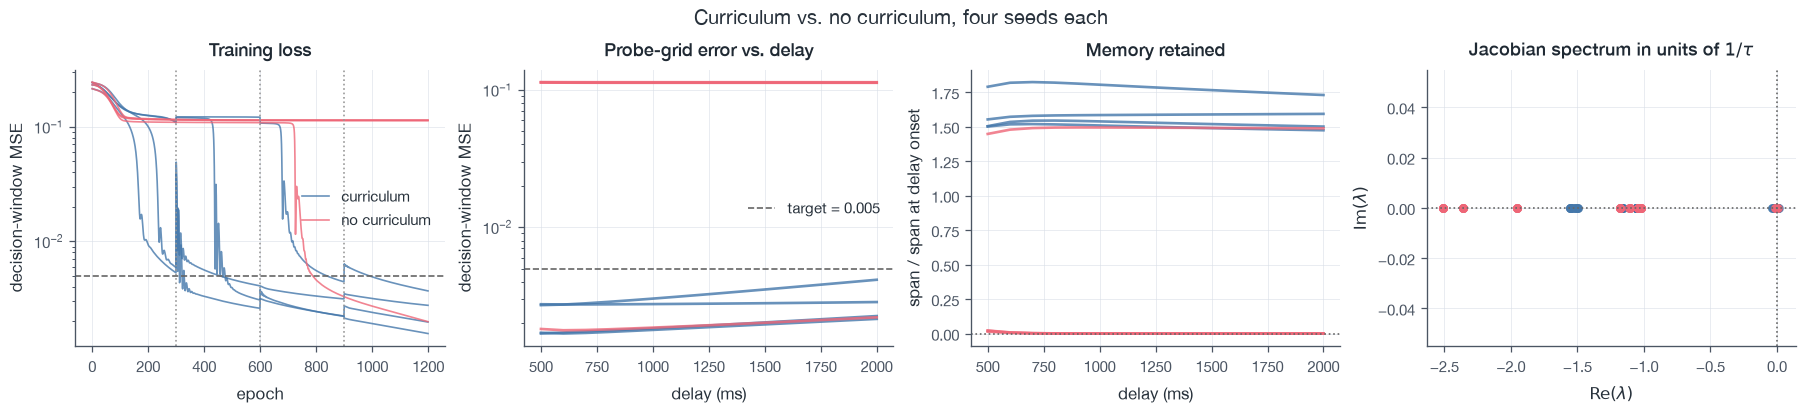

In [14]:
# Learning, generalization across delays, memory retention, and the local spectrum.
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), constrained_layout=True)
probe_ms = 20 * PROBE_DELAYS
cohort_colors = (COLORS["blue"], COLORS["red"])

for (cohort, label), color in zip(COHORTS, cohort_colors):
    for index, result in enumerate(cohort):
        legend_label = label if index == 0 else None
        axes[0].plot(result["losses"], color=color, lw=1, alpha=0.8, label=legend_label)
        axes[1].plot(probe_ms, result["probe_mse"], color=color, alpha=0.8)
        axes[2].plot(probe_ms, result["retained_span"], color=color, alpha=0.8)
        eigenvalues = result["eigenvalues"]
        axes[3].scatter(eigenvalues.real, eigenvalues.imag, color=color, s=18, alpha=0.7)

for boundary in range(STAGE_EPOCHS, len(curriculum_cohort[0]["losses"]), STAGE_EPOCHS):
    axes[0].axvline(boundary, color="0.6", ls=":", lw=1)
axes[0].axhline(TARGET_LOSS, color="0.4", ls="--", lw=1)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("decision-window MSE")
axes[0].set_title("Training loss")
axes[0].legend()

axes[1].axhline(TARGET_LOSS, color="0.4", ls="--", lw=1, label=f"target = {TARGET_LOSS:g}")
axes[1].set_yscale("log")
axes[1].set_xlabel("delay (ms)")
axes[1].set_ylabel("decision-window MSE")
axes[1].set_title("Probe-grid error vs. delay")
axes[1].legend()

axes[2].axhline(0, color="0.4", ls=":", lw=1)
axes[2].set_xlabel("delay (ms)")
axes[2].set_ylabel("span / span at delay onset")
axes[2].set_title("Memory retained")

axes[3].axhline(0, color="0.4", ls=":", lw=1)
axes[3].axvline(0, color="0.4", ls=":", lw=1)
axes[3].set_xlabel(r"$\mathrm{Re}(\lambda)$")
axes[3].set_ylabel(r"$\mathrm{Im}(\lambda)$")
axes[3].set_title(r"Jacobian spectrum in units of $1/\tau$")

fig.suptitle("Curriculum vs. no curriculum, four seeds each")
plt.show()

## 11. A fixed delay is solved by a clock, not by a memory

Sections 2–7 trained on a single fixed delay: stimulus 2 always arrives at step
60, and the decision window is always the last five steps. Nothing in that task
demands a *stable* memory. The network knows exactly when the readout is due, so
it can encode $f_1$ in a state that moves predictably and read that state out
when the motion reaches the right phase.

That is what it does. Retraining the section 4 paradigm across four seeds, three
of four solve the task with MSE 0.0002, and **all four have complex
eigenvalues**: $|\mathrm{Im}\,\lambda| = 0.20$–$0.29$ in units of $1/\tau$, with
real parts within 0.03 of zero. The latent state rotates through the delay with
a period near 2500 ms — comparable to the delay itself — rather than settling.
The trajectory panels show it directly: these states are still moving when the
delay ends, while the section 10 networks are flat from 500 ms onward.

`fixed_delay_trials` can move stimulus 2, which asks what that solution is worth
at delays it never saw. The answer is: nothing much. Error at the trained 980 ms
delay is 0.0002–0.0003, roughly ten times *better* than the line attractors
manage — a specialist beats a generalist on its own delay. Move the stimulus and
it degrades by two orders of magnitude, up to 0.047–0.080. The curriculum
networks stay between 0.002 and 0.004 across the entire 500–2000 ms range.

So the two paradigms learn genuinely different objects, and the difference is
visible in the spectrum: rotation off the real axis for a fixed delay, a real
eigenvalue pinned at zero for a random one.

One caveat against overreading this. A fixed delay *permits* timing-dependent
solutions but does not dictate which one. Training the same fixed 1000 ms delay
through `train_variable_delay` instead — different stimulus widths, different
readout placement, full-batch — produced a learner that also exploits the fixed
timing yet has purely real eigenvalues, expanding its memory span 2.9× instead
of rotating. Rotation is what this paradigm reliably finds, not the only clock
available. The robust claim is the contrast in *generalization*: fixed-delay
solutions are tuned to one interval, and randomizing the delay is what forces a
stationary attractor.

Note also that the two cohorts differ in trainer — `train_model` uses minibatch
Adam here, `train_variable_delay` full batch in section 10. That was checked:
rerunning section 10 with minibatch training gives the same 4/4 versus 1/4 split
and real eigenvalues in every learner, so the trainer is not what produces the
difference in solution type.

In [15]:
# Retrain the section 4 paradigm across seeds, then probe it at other delays.
STIMULUS_WIDTH = SECOND_STIMULUS_WINDOW[1] - SECOND_STIMULUS_WINDOW[0]
DECISION_GAP = TRIAL_LENGTH - DECISION_STEPS - (SECOND_STIMULUS_WINDOW[1] + 1)
# Onsets that still leave room for the decision window; the last is the trained one.
PROBE_ONSETS = np.arange(25, SECOND_STIMULUS_WINDOW[0] + 1, 5)


def fixed_delay_trials(frequencies, second_start=SECOND_STIMULUS_WINDOW[0]):
    """Section 2 trials, with stimulus 2 optionally moved to probe other delays.

    The decision window keeps its offset from the end of stimulus 2, so moving
    the stimulus moves the readout with it.
    """
    amplitudes = delay_task.stimulus_amplitudes(frequencies)
    inputs = np.zeros((len(amplitudes), TRIAL_LENGTH), dtype=np.float32)
    first_start, first_end = FIRST_STIMULUS_WINDOW
    inputs[:, first_start : first_end + 1] = amplitudes[:, 0, None]
    inputs[:, second_start : second_start + STIMULUS_WIDTH + 1] = amplitudes[:, 1, None]

    targets = amplitudes[:, 0] - amplitudes[:, 1]
    decision_start = second_start + STIMULUS_WIDTH + 1 + DECISION_GAP
    return (
        torch.as_tensor(inputs),
        torch.as_tensor(targets, dtype=torch.float32),
        decision_start,
    )


def fixed_delay_diagnostics(model):
    """Delay-period latent states, error at each probe delay, local spectrum."""
    neutral = np.full_like(FREQUENCIES, FREQUENCIES.mean())
    sweep_inputs, _, _ = fixed_delay_trials(np.column_stack((FREQUENCIES, neutral)))
    with torch.no_grad():
        _, states = model(sweep_inputs)
        coordinates = states @ torch.linalg.pinv(model.m).T
    memory = coordinates[:, FIRST_STIMULUS_WINDOW[1] + 1 : SECOND_STIMULUS_WINDOW[0] + 1]

    probe_mse = []
    for onset in PROBE_ONSETS:
        inputs, targets, decision_start = fixed_delay_trials(
            delay_task.frequency_pair_grid(), onset
        )
        with torch.no_grad():
            outputs, _ = model(inputs)
        window = outputs[:, decision_start : decision_start + DECISION_STEPS]
        probe_mse.append((window - targets[:, None]).square().mean().item())

    memory = memory.cpu().numpy()
    onset_span = np.linalg.norm(memory[-1, 0] - memory[0, 0])
    return {
        "memory_coordinates": memory,
        "probe_mse": np.asarray(probe_mse),
        "retained_span": np.linalg.norm(memory[-1] - memory[0], axis=-1) / onset_span,
        "eigenvalues": delay_eigenvalues(model, torch.as_tensor(memory[:, -1])),
    }


def train_fixed_delay(seed):
    """Train exactly as in section 4: fixed windows, minibatch Adam."""
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    model = LowRankRNN(NUM_UNITS, rank=RANK)
    inputs, targets, _ = fixed_delay_trials(
        rng.choice(FREQUENCIES, size=(NUM_TRAIN_TRIALS, 2))
    )
    losses = train_model(
        model, inputs, targets, decision_steps=DECISION_STEPS, log_every=None
    )
    model.eval()
    return {
        "seed": seed,
        "model": model,
        "losses": np.asarray(losses),
        **fixed_delay_diagnostics(model),
    }


fixed_cohort = [train_fixed_delay(seed) for seed in COHORT_SEEDS]
for result in fixed_cohort:
    eigenvalues = result["eigenvalues"]
    print(
        f"fixed delay, seed {result['seed']}: "
        f"train MSE={result['losses'][-1]:.4f}, "
        f"probe at trained delay={result['probe_mse'][-1]:.4f}, "
        f"probe max={result['probe_mse'].max():.4f}, "
        f"lead Re={eigenvalues[:, 0].real.mean():+.3f}, "
        f"max |Im λ|={np.abs(eigenvalues.imag).max():.4f}"
    )

fixed delay, seed 2026: train MSE=0.0002, probe at trained delay=0.0003, probe max=0.0470, lead Re=-0.029, max |Im λ|=0.2024
fixed delay, seed 2027: train MSE=0.0002, probe at trained delay=0.0002, probe max=0.0801, lead Re=+0.023, max |Im λ|=0.2767
fixed delay, seed 2028: train MSE=0.0002, probe at trained delay=0.0003, probe max=0.0711, lead Re=+0.013, max |Im λ|=0.2750
fixed delay, seed 2029: train MSE=0.1128, probe at trained delay=0.1113, probe max=0.1230, lead Re=-0.750, max |Im λ|=0.2878


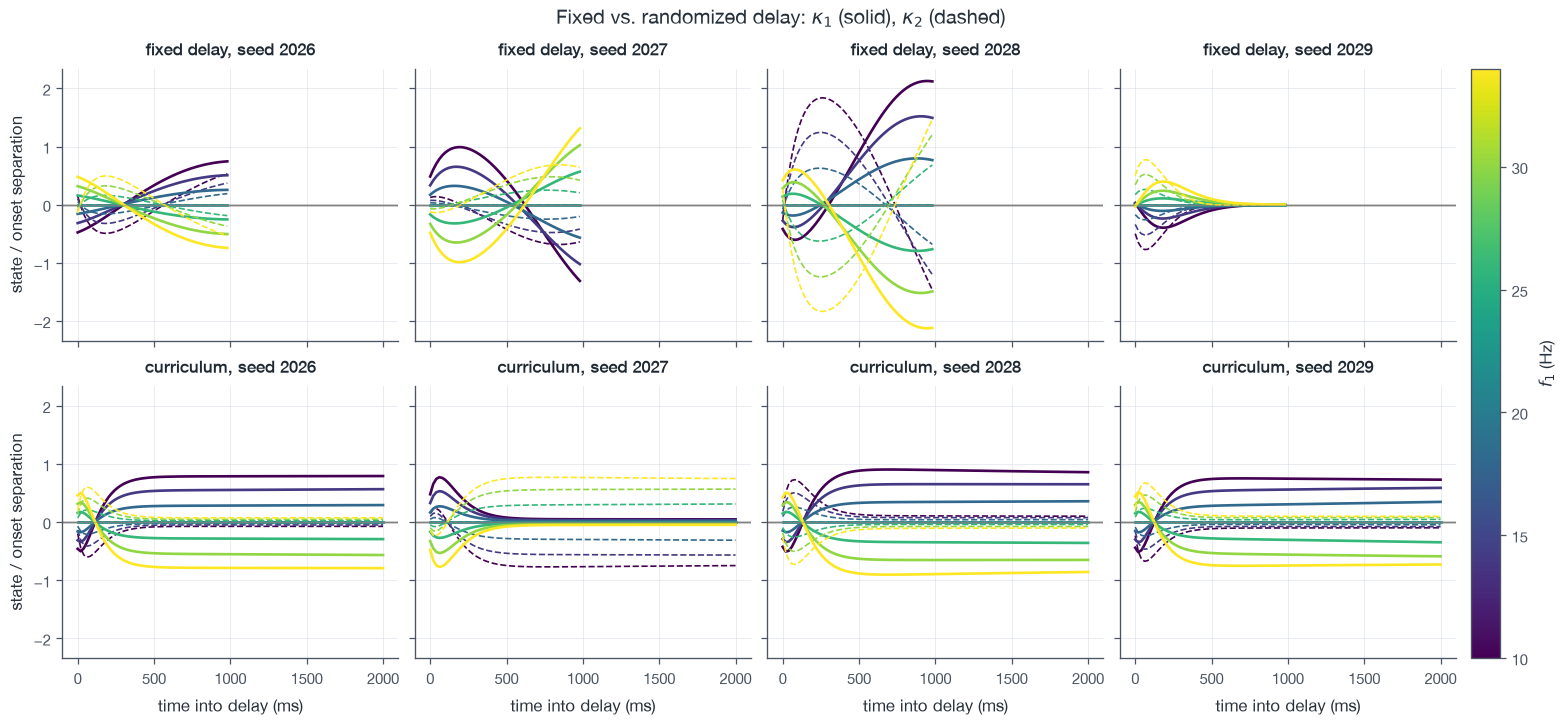

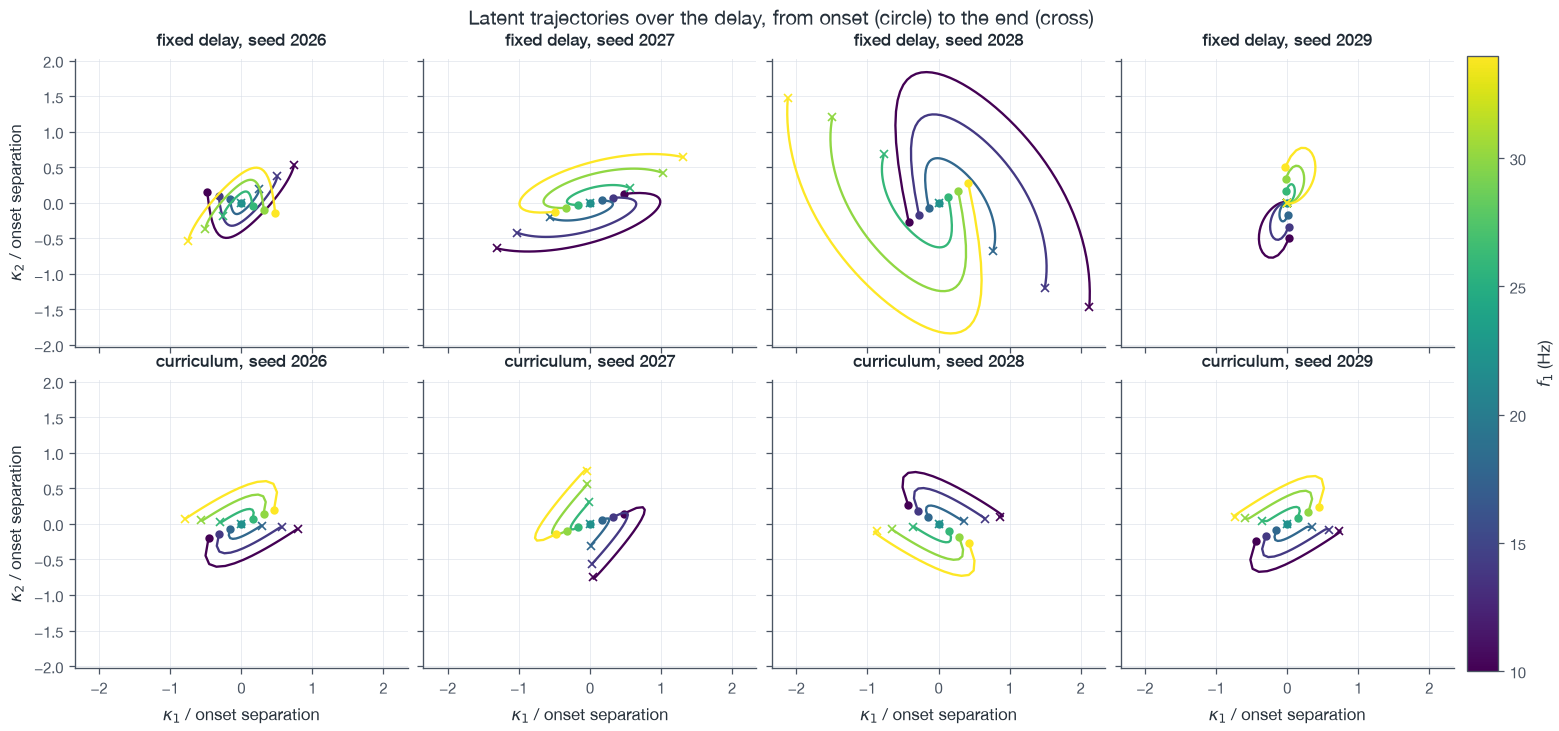

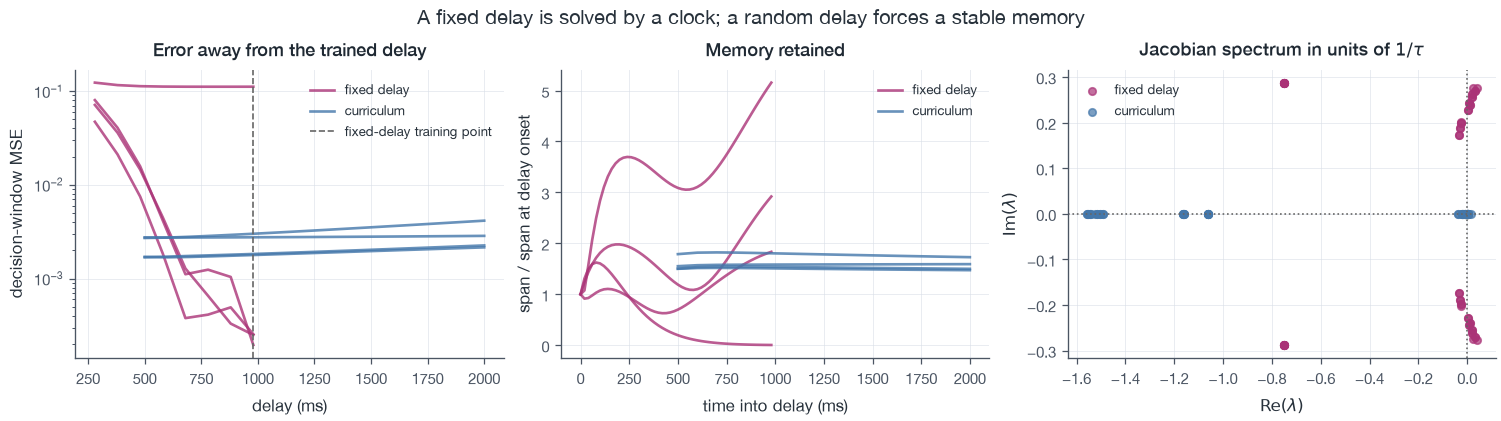

In [16]:
# The section 10 panels again, now contrasting a fixed delay with the curriculum.
FIXED_COHORTS = ((fixed_cohort, "fixed delay"), (curriculum_cohort, "curriculum"))

fig, axes = plot_cohort_grid(
    draw_time_course,
    r"Fixed vs. randomized delay: $\kappa_1$ (solid), $\kappa_2$ (dashed)",
    cohorts=FIXED_COHORTS,
)
for axis in axes[-1]:
    axis.set_xlabel("time into delay (ms)")
for row in axes:
    row[0].set_ylabel("state / onset separation")
plt.show()

fig, axes = plot_cohort_grid(
    draw_plane,
    "Latent trajectories over the delay, from onset (circle) to the end (cross)",
    cohorts=FIXED_COHORTS,
)
for axis in axes[-1]:
    axis.set_xlabel(r"$\kappa_1$ / onset separation")
for row in axes:
    row[0].set_ylabel(r"$\kappa_2$ / onset separation")
plt.show()


# Delay generalization, memory retention, and the local spectrum.
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.5), constrained_layout=True)
fixed_delay_ms = 20 * (PROBE_ONSETS - FIRST_STIMULUS_WINDOW[1] - 1)
fixed_color, curriculum_color = COLORS["purple"], COLORS["blue"]

for index, result in enumerate(fixed_cohort):
    label = "fixed delay" if index == 0 else None
    axes[0].plot(fixed_delay_ms, result["probe_mse"], color=fixed_color, alpha=0.8, label=label)
    axes[1].plot(
        20 * np.arange(len(result["retained_span"])),
        result["retained_span"],
        color=fixed_color,
        alpha=0.8,
        label=label,
    )
    axes[2].scatter(
        result["eigenvalues"].real,
        result["eigenvalues"].imag,
        color=fixed_color,
        s=20,
        alpha=0.7,
        label=label,
    )

for index, result in enumerate(curriculum_cohort):
    label = "curriculum" if index == 0 else None
    axes[0].plot(20 * PROBE_DELAYS, result["probe_mse"], color=curriculum_color, alpha=0.8, label=label)
    axes[1].plot(
        20 * PROBE_DELAYS, result["retained_span"], color=curriculum_color, alpha=0.8, label=label
    )
    axes[2].scatter(
        result["eigenvalues"].real,
        result["eigenvalues"].imag,
        color=curriculum_color,
        s=20,
        alpha=0.7,
        label=label,
    )

axes[0].axvline(
    fixed_delay_ms[-1], color="0.4", ls="--", lw=1, label="fixed-delay training point"
)
axes[0].set_yscale("log")
axes[0].set_xlabel("delay (ms)")
axes[0].set_ylabel("decision-window MSE")
axes[0].set_title("Error away from the trained delay")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("time into delay (ms)")
axes[1].set_ylabel("span / span at delay onset")
axes[1].set_title("Memory retained")
axes[1].legend(fontsize=8)

axes[2].axhline(0, color="0.4", ls=":", lw=1)
axes[2].axvline(0, color="0.4", ls=":", lw=1)
axes[2].set_xlabel(r"$\mathrm{Re}(\lambda)$")
axes[2].set_ylabel(r"$\mathrm{Im}(\lambda)$")
axes[2].set_title(r"Jacobian spectrum in units of $1/\tau$")
axes[2].legend(fontsize=8)

fig.suptitle("A fixed delay is solved by a clock; a random delay forces a stable memory")
plt.show()